In [6]:
## Modélisation Prédictive : Heart Disease Risk

In [8]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv('healthcare_synthetic_data.csv')


data["SBMI"] = np.sqrt(data["BMI"])
data["SWeight"] = np.sqrt(data["Weight_kg"])
data["S_Fasting_Blood_Sugar"] = np.sqrt(data["Fasting_Blood_Sugar"])
data["L_Height_cm"] = np.log(data["Height_cm"])


if 'Patient_ID' in data.columns:
    data = data.drop(columns=['Patient_ID'])


cat_vars = [
    "Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
    "Physical_Activity_Level", "Stress_Level", "Heart_Disease_Risk", "Sleep_Hours"
]

for var in cat_vars:
    data[var] = data[var].astype('category')

gender_map = {0: "Female", 1: "Male"}
data["Gender"] = data["Gender"].map(gender_map).astype('category')

print("--- Aperçu des types et valeurs manquantes ---")
print(data.info())

print("\n--- Statistiques descriptives (Numériques) ---")
print(data.describe())

print("\n--- Statistiques descriptives (Catégorielles) ---")
print(data.describe(include=['category']))

--- Aperçu des types et valeurs manquantes ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      15000 non-null  int64   
 1   Gender                   15000 non-null  category
 2   Height_cm                15000 non-null  float64 
 3   Weight_kg                15000 non-null  float64 
 4   BMI                      15000 non-null  float64 
 5   Systolic_BP              15000 non-null  int64   
 6   Diastolic_BP             15000 non-null  int64   
 7   Cholesterol_Total        15000 non-null  int64   
 8   Cholesterol_LDL          15000 non-null  int64   
 9   Cholesterol_HDL          15000 non-null  int64   
 10  Fasting_Blood_Sugar      15000 non-null  int64   
 11  Smoking_Status           15000 non-null  category
 12  Alcohol_Consumption      15000 non-null  category
 13  Physical_Activity_Level  

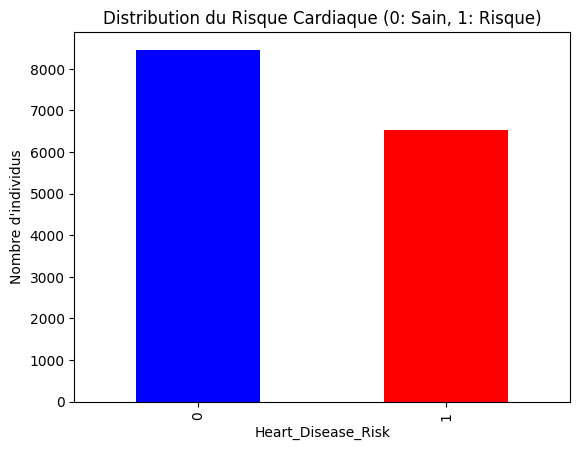

,Gender_Male,Smoking_Status_1,Family_History_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Stress_Level_2,Stress_Level_3,...,SBMI,SWeight,S_Fasting_Blood_Sugar,L_Height_cm,Age,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL
0,False,False,False,True,False,False,False,True,False,False,...,4.878524,7.162402,9.110434,4.989752,60,140,89,217,151,52
1,False,False,False,False,False,True,False,False,False,False,...,5.412947,8.752143,10.770330,5.086361,53,128,81,203,119,38
2,True,False,False,False,False,False,False,False,False,False,...,5.504544,9.612492,9.486833,5.163070,62,141,100,173,124,45
3,True,False,False,False,False,True,False,False,True,False,...,4.785394,8.300602,9.000000,5.155024,73,136,96,193,117,45
4,True,False,False,True,False,False,True,False,True,False,...,5.000000,8.933085,8.888194,5.185149,52,122,80,236,153,41


In [9]:

qual_cols = ["Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
             "Physical_Activity_Level", "Stress_Level", "Sleep_Hours"]

df_dummies = pd.get_dummies(data[qual_cols], drop_first=True)

quant_cols = ["SBMI", "SWeight", "S_Fasting_Blood_Sugar", "L_Height_cm", 
              "Age", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", 
              "Cholesterol_LDL", "Cholesterol_HDL"]

df_quant = data[quant_cols]

X = pd.concat([df_dummies, df_quant], axis=1)

y = data["Heart_Disease_Risk"].map(lambda x: 1 if x in ["Yes", 1, "1"] else 0)

y.value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Distribution du Risque Cardiaque (0: Sain, 1: Risque)")
plt.xlabel("Heart_Disease_Risk")
plt.ylabel("Nombre d'individus")
plt.show()

X.head()



In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


print(f"Taille de l'échantillon d'apprentissage : {X_train.shape[0]} individus")
print(f"Taille de l'échantillon de test : {X_test.shape[0]} individus")

Taille de l'échantillon d'apprentissage : 12000 individus
Taille de l'échantillon de test : 3000 individus


Cette étape fondamentale pour évaluer la capacité de généralisation des algorithmes. En isolant une portion des données que le modèle ne verra jamais durant sa phase d'entraînement, on simule l'arrivée de nouveaux patients afin de mesurer ses performances réelles. Cette procédure est la seule manière fiable de détecter l'overfitting.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Prévision par modèles linéaires